In [20]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from IPython.display import FileLink, display

# Dataset Initialization

In [26]:
#Data-Import

df = pd.read_csv("/kaggle/input/energy-production/Gesamterzeugung_hourly.csv", index_col='Datum', parse_dates=True)
display(df)


,Stromerzeugung Gesamt
Datum,
2015-01-01 00:00:00,51238.75
2015-01-01 01:00:00,49749.00
2015-01-01 02:00:00,49014.75
2015-01-01 03:00:00,47954.75
2015-01-01 04:00:00,48187.00
...,...
2018-12-31 19:00:00,55441.00
2018-12-31 20:00:00,54499.50
2018-12-31 21:00:00,54526.75


In [27]:
# Normalization parameters from the original training
Power_train = df["Stromerzeugung Gesamt"]["2015-01-01 00:00:00":"2018-06-30 23:00:00"]
Power_valid = df["Stromerzeugung Gesamt"]["2018-07-01 00:00:00":"2018-12-31 23:00:00"]

mean = Power_train.mean()
std = Power_train.std()

# Create normalized datasets
Power_train_norm = (Power_train - mean) / std
Power_valid_norm = (Power_valid - mean) / std

datasets = [
    ("Power_train", Power_train),
    ("Power_valid", Power_valid),
    ("Power_train_norm", Power_train_norm),
    ("Power_valid_norm", Power_valid_norm),
]

print(f"{'Dataset':<20} {'Count':<8} {'Mean':<12} {'Std':<12} {'Min':<12} {'Max':<12}")
print("-" * 78)

# First 2 rows without decimal places
for i in range(2):
    name, data = datasets[i]
    desc = data.describe()
    print(f"{name:<20} {desc['count']:<8.0f} {desc['mean']:<12.0f} {desc['std']:<12.0f} {desc['min']:<12.0f} {desc['max']:<12.0f}")

print()

# Last 2 rows with decimal places
for i in range(2, 4):
    name, data = datasets[i]
    desc = data.describe()
    print(f"{name:<20} {desc['count']:<8.0f} {desc['mean']:<12.2f} {desc['std']:<12.2f} {desc['min']:<12.2f} {desc['max']:<12.2f}")


Dataset              Count    Mean         Std          Min          Max         
------------------------------------------------------------------------------
Power_train          30648    60689        9845         0            114548      
Power_valid          4416     61869        9447         38536        101353      

Power_train_norm     30648    0.00         1.00         -6.16        5.47        
Power_valid_norm     4416     0.12         0.96         -2.25        4.13        


# Data Visualization

Plot saved at: power_generation_germany_2015_2018.png


/kaggle/working/power_generation_germany_2015_2018.png

File size: 1.33 MB


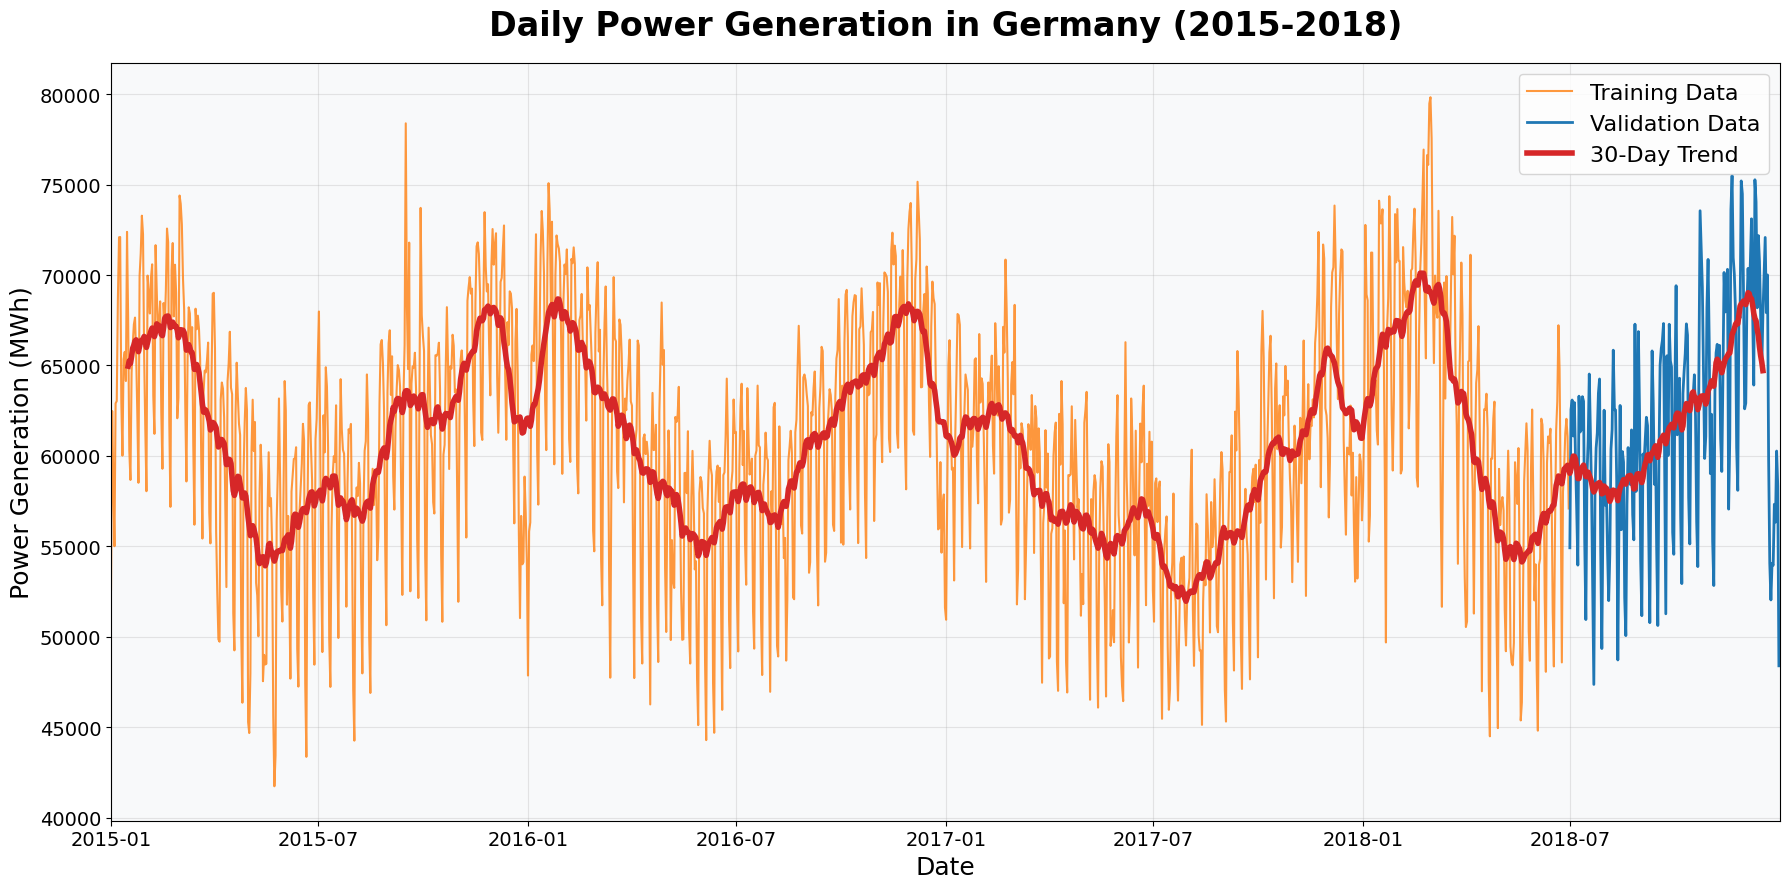

In [24]:
# Slide 1: Overview
fig, ax = plt.subplots(figsize=(18, 9))  

ax.plot(period_train_daily.index, period_train_daily.values,
        color='#ff7f0e', alpha=0.8, linewidth=1.5, label='Training Data')

ax.plot(period_valid_daily.index, period_valid_daily.values,
        color='#1f77b4', linewidth=2, label='Validation Data')

ax.plot(trend_full.index, trend_full.values,
        color='#d62728', linewidth=4, label='30-Day Trend')

# Set X-axis limits
ax.set_xlim(pd.Timestamp('2015-01-01 00:00:00'),
            pd.Timestamp('2018-12-31 23:00:00'))

# Large, readable fonts for presentation
ax.set_title('Daily Power Generation in Germany (2015-2018)',
             fontsize=24, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=18)
ax.set_ylabel('Power Generation (MWh)', fontsize=18)
ax.legend(fontsize=16, loc='upper right')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', which='major', labelsize=14)

# Light background color for better visibility
ax.set_facecolor('#f8f9fa')
plt.tight_layout()

# Save plot and create download link
file_path = 'power_generation_germany_2015_2018.png'
fig.savefig(file_path, dpi=300, bbox_inches='tight', facecolor='white')

print(f"Plot saved at: {file_path}")
display(FileLink(file_path))

# Additional information
file_size = os.path.getsize(file_path) / (1024 * 1024)  # MB
print(f"File size: {file_size:.2f} MB")

plt.show()


Validation dataset: 2018-07-01 to 2018-12-31 (full)
Display window: 2018-08-01 to 2018-08-30 (30 days)
24h Trend: ✅ Enabled
30d Trend: ✅ Enabled


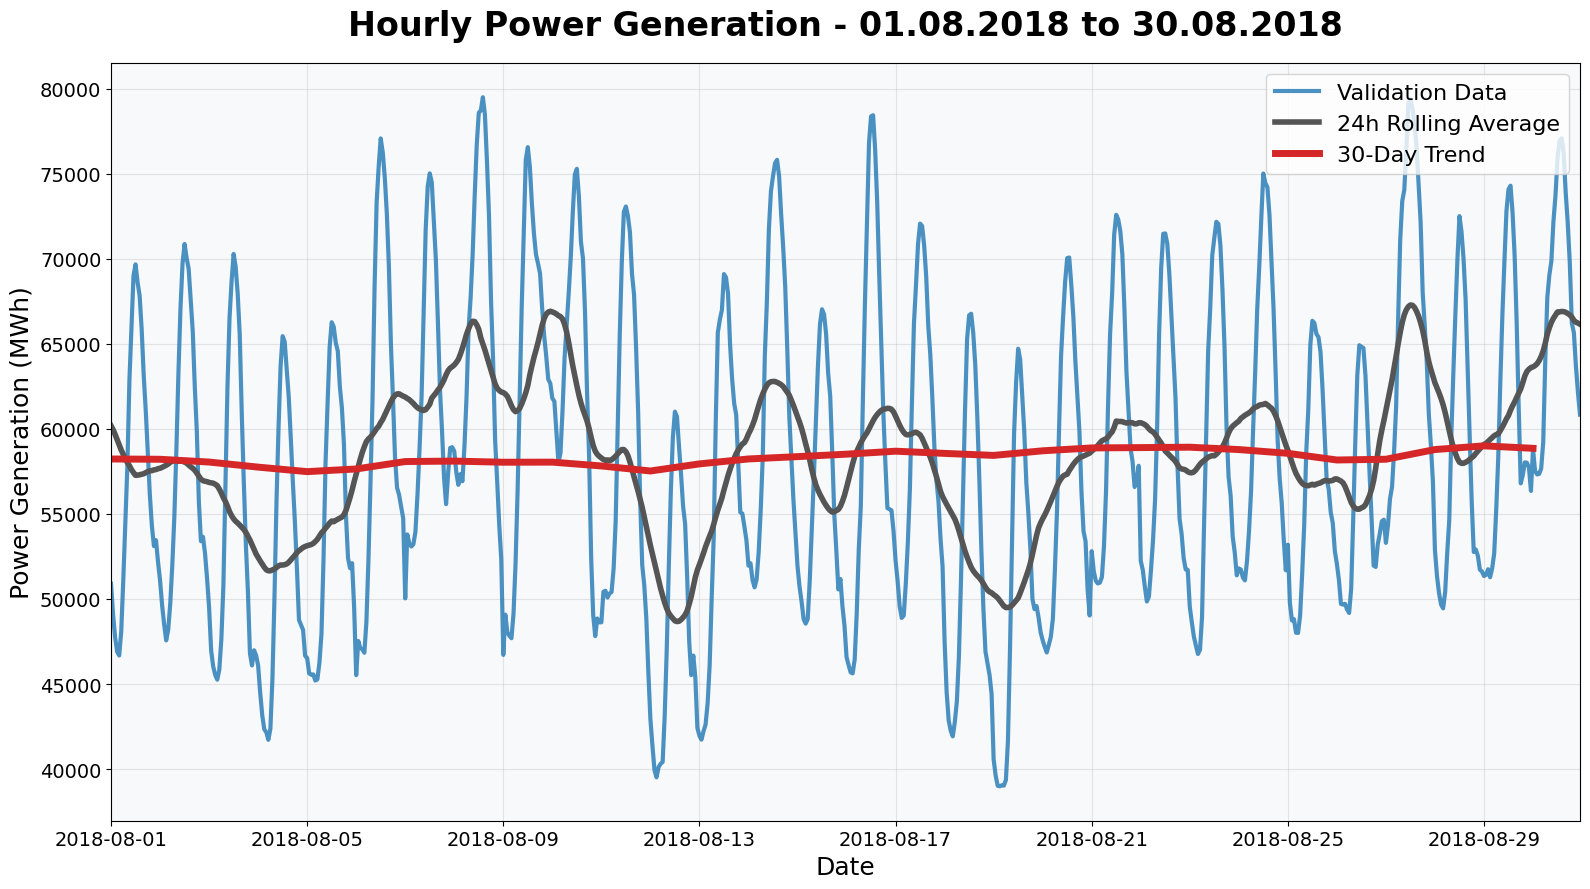

/kaggle/working/power_generation_presentation.png

In [25]:
# ===== EXTENDED CONFIG =====
config = {
    'start_date': '2018-08-01',          # Start date for display window
    'duration_days': 30,                 # Duration in days for display window
    'show_24h_trend': True,              # Show rolling 24-hour average
    'show_30d_trend': True,               # Show 30-day trend
    'file_path': 'power_generation_presentation.png'
}

# FIXED VALIDATION DATASET
period_valid_hourly = df.loc['2018-07-01 00:00:00':'2018-12-31 23:00:00', 'Stromerzeugung Gesamt']
period_valid_daily = df.loc['2018-07-01 00:00:00':'2018-12-31 23:00:00', 'Stromerzeugung Gesamt'].resample('D').mean()

# Calculate trends for full validation dataset (only if activated)
if config['show_30d_trend']:
    trend_30_days = period_valid_daily.rolling(window=30, center=True).mean()

if config['show_24h_trend']:
    trend_daily = period_valid_hourly.rolling(window=24, center=True).mean()

# Calculate display window
start_datetime = pd.to_datetime(config['start_date'])
end_datetime = start_datetime + pd.Timedelta(days=config['duration_days'] - 1, hours=23)

# Print configuration info
print(f"Validation dataset: 2018-07-01 to 2018-12-31 (full)")
print(f"Display window: {start_datetime.strftime('%Y-%m-%d')} to {end_datetime.strftime('%Y-%m-%d')} ({config['duration_days']} days)")
print(f"24h Trend: {'✅ Enabled' if config['show_24h_trend'] else '❌ Disabled'}")
print(f"30d Trend: {'✅ Enabled' if config['show_30d_trend'] else '❌ Disabled'}")

# Filter data for display window
display_hourly = period_valid_hourly.loc[start_datetime:end_datetime]

if config['show_30d_trend']:
    display_30_trend = trend_30_days.loc[start_datetime:end_datetime]

if config['show_24h_trend']:
    display_daily_trend = trend_daily.loc[start_datetime:end_datetime]

# Create plot in presentation format
fig, ax = plt.subplots(figsize=(16, 9))  # 16:9 format for presentations

# Hourly validation data - THICK
ax.plot(display_hourly.index, display_hourly.values,
        color='#1f77b4', alpha=0.8, linewidth=3, label='Validation Data')

# Rolling 24-hour average - THICK
if config['show_24h_trend']:
    ax.plot(display_daily_trend.index, display_daily_trend.values,
            color='#555555', linewidth=4, label='24h Rolling Average')

# 30-day trend - THICK
if config['show_30d_trend']:
    ax.plot(display_30_trend.index, display_30_trend.values,
            color='#d62728', linewidth=5, label='30-Day Trend')

# Set X-axis range
ax.set_xlim(start_datetime, end_datetime)

# Large, readable fonts for presentation
ax.set_title(f'Hourly Power Generation - {start_datetime.strftime("%d.%m.%Y")} to {end_datetime.strftime("%d.%m.%Y")}',
             fontsize=24, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=18)
ax.set_ylabel('Power Generation (MWh)', fontsize=18)
ax.legend(fontsize=16, loc='upper right')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', which='major', labelsize=14)

# Light background for better visibility
ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.savefig(config['file_path'], dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Show download link
display(FileLink(config['file_path']))
